In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('online_retail_II.csv')

# Quick preview
print(df.head())
print(df.info())
df.isnull().sum()

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice 

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
# Count negative quantities
negative_quantity = (df['Quantity'] < 0).sum()

print("Negative Quantity values:", negative_quantity)

Negative Quantity values: 22950


In [ ]:
numeric_cols = df.select_dtypes(include='number')

(numeric_cols < 0).sum()

NameError: name 'df' is not defined

In [ ]:
# Number of negative quantities
print(df[df['Quantity'] < 0].shape)

# View some negative quantity transactions
df[df['Quantity'] < 0].head(10)

(22950, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [ ]:
negative_orders = df[df['Quantity'] < 0]

negative_orders['Invoice'].astype(str).str.startswith('C').value_counts()

,count
Invoice,
True,19493
False,3457


In [ ]:
df[(df['Quantity'] < 0) &
   (~df['Invoice'].astype(str).str.startswith('C'))]['StockCode'].value_counts().head(20)

,count
StockCode,
22423,12
46000M,6
22719,6
82494L,6
84016,5
85017A,5
21830,5
85175,5
47566B,5


In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Load Data
# =========================

df = pd.read_csv("online_retail_II.csv")

print("Original shape:", df.shape)
display(df.head())


# =========================
# 2. Standardize Column Names
# =========================

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print(df.columns)


# =========================
# 3. Basic Data Check
# =========================

print("Data types:")
print(df.info())

print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())


# =========================
# 4. Remove Duplicate Rows
# =========================

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


# =========================
# 5. Convert Data Types
# =========================

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df["Invoice"] = df["Invoice"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

print(df.info())


# =========================
# 6. Create Transaction Type
# =========================

df["Invoice_Prefix"] = df["Invoice"].str[0]

df["Transaction_Type"] = np.where(
    df["Invoice"].str.startswith("C"), "Return/Cancelled",
    np.where(df["Invoice"].str.startswith("A"), "Adjustment", "Sale")
)

df["Transaction_Type"].value_counts()


# =========================
# 7. Investigate Negative Values
# =========================

print("Negative Quantity:", (df["Quantity"] < 0).sum())
print("Negative Price:", (df["Price"] < 0).sum())
print("Zero Price:", (df["Price"] == 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())

negative_orders = df[df["Quantity"] < 0]

negative_orders["Transaction_Type"].value_counts()


# =========================
# 8. Create Revenue Column
# =========================

df["Revenue"] = df["Quantity"] * df["Price"]


# =========================
# 9. Create Date Features
# =========================

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["Week"] = df["InvoiceDate"].dt.isocalendar().week
df["Day"] = df["InvoiceDate"].dt.day
df["Day_of_Week"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour
df["Date"] = df["InvoiceDate"].dt.date


# =========================
# 10. Create Separate Datasets
# =========================

# Completed sales only
sales_df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0) &
    (~df["Invoice"].str.startswith("C")) &
    (~df["Invoice"].str.startswith("A"))
].copy()

# Returns / cancellations
returns_df = df[
    (df["Quantity"] < 0) |
    (df["Invoice"].str.startswith("C"))
].copy()

# Adjustments
adjustments_df = df[
    df["Invoice"].str.startswith("A")
].copy()

# Customer-level dataset for marketing analysis
marketing_df = sales_df.dropna(subset=["Customer_ID"]).copy()

# Product/demand-level dataset for supply chain analysis
supply_chain_df = sales_df.copy()


# =========================
# 11. Final Data Quality Summary
# =========================

print("Original cleaned base shape:", df.shape)
print("Sales dataset shape:", sales_df.shape)
print("Returns dataset shape:", returns_df.shape)
print("Adjustments dataset shape:", adjustments_df.shape)
print("Marketing dataset shape:", marketing_df.shape)
print("Supply chain dataset shape:", supply_chain_df.shape)

print("\nMissing values in sales dataset:")
print(sales_df.isnull().sum())

print("\nTransaction type counts:")
print(df["Transaction_Type"].value_counts())


# =========================
# 12. Save Cleaned Files
# =========================

df.to_csv("01_cleaned_master_dataset.csv", index=False)
sales_df.to_csv("02_sales_dataset.csv", index=False)
returns_df.to_csv("03_returns_dataset.csv", index=False)
adjustments_df.to_csv("04_adjustments_dataset.csv", index=False)
marketing_df.to_csv("05_marketing_dataset.csv", index=False)
supply_chain_df.to_csv("06_supply_chain_dataset.csv", index=False)

print("Files saved successfully.")

Original shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country'],
      dtype='object')
Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer_ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer_ID    243007
Country             0
dtype: int64
Duplicate rows: 34335
Sha

In [ ]:
import pandas as pd

# =========================
# 1. Load Data
# =========================

df = pd.read_csv("online_retail_II.csv")

print("Original shape:", df.shape)


# =========================
# 2. Standardize Column Names
# =========================

df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print("Column names:")
print(df.columns)


# =========================
# 3. Remove Duplicate Rows
# =========================

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)


# =========================
# 4. Convert Data Types
# =========================

df["Invoice"] = df["Invoice"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")


# =========================
# 5. Remove Null Values
# =========================

df = df.dropna()

print("After removing null values:", df.shape)


# =========================
# 6. Remove Cancelled and Adjustment Invoices
# =========================

df = df[
    ~df["Invoice"].str.startswith("C") &
    ~df["Invoice"].str.startswith("A")
]

print("After removing cancelled/adjustment invoices:", df.shape)


# =========================
# 7. Remove Negative and Zero Values
# =========================

df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
]

print("After removing negative/zero Quantity and Price:", df.shape)


# =========================
# 8. Create Revenue Column
# =========================

df["Revenue"] = df["Quantity"] * df["Price"]


# =========================
# 9. Create Date Features
# =========================

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["Week"] = df["InvoiceDate"].dt.isocalendar().week
df["Day"] = df["InvoiceDate"].dt.day
df["Day_of_Week"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour
df["Date"] = df["InvoiceDate"].dt.date


# =========================
# 10. Final Quality Check
# =========================

print("Final cleaned dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNegative Quantity:", (df["Quantity"] < 0).sum())
print("Zero Quantity:", (df["Quantity"] == 0).sum())
print("Negative Price:", (df["Price"] < 0).sum())
print("Zero Price:", (df["Price"] == 0).sum())
print("Cancelled invoices:", df["Invoice"].str.startswith("C").sum())
print("Adjustment invoices:", df["Invoice"].str.startswith("A").sum())
print("Duplicate rows:", df.duplicated().sum())


# =========================
# 11. Save One Cleaned File
# =========================

df.to_csv("cleaned_online_retail_II.csv", index=False)

print("\nCleaned file saved as: cleaned_online_retail_II.csv")

Original shape: (1067371, 8)
Column names:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer_ID', 'Country'],
      dtype='object')
After removing duplicates: (1033036, 8)
After removing null values: (797885, 8)
After removing cancelled/adjustment invoices: (779495, 8)
After removing negative/zero Quantity and Price: (779425, 8)
Final cleaned dataset shape: (779425, 18)

Missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer_ID    0
Country        0
Revenue        0
Year           0
Month          0
Month_Name     0
Quarter        0
Week           0
Day            0
Day_of_Week    0
Hour           0
Date           0
dtype: int64

Negative Quantity: 0
Zero Quantity: 0
Negative Price: 0
Zero Price: 0
Cancelled invoices: 0
Adjustment invoices: 0
Duplicate rows: 0

Cleaned file saved as: cleaned_online_retail_II.csv


In [ ]:
import pandas as pd

# =========================
# 1. Load Data
# =========================

df = pd.read_csv("online_retail_II.csv")

print("Original Shape:", df.shape)

# =========================
# 2. Standardize Column Names
# =========================

df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
)

# =========================
# 3. Data Quality Summary (BEFORE Cleaning)
# =========================

summary = {}

summary["Original Rows"] = len(df)
summary["Original Columns"] = len(df.columns)
summary["Duplicate Rows"] = df.duplicated().sum()
summary["Missing Description"] = df["Description"].isnull().sum()
summary["Missing Customer_ID"] = df["Customer_ID"].isnull().sum()
summary["Negative Quantity"] = (df["Quantity"] < 0).sum()
summary["Zero Quantity"] = (df["Quantity"] == 0).sum()
summary["Negative Price"] = (df["Price"] < 0).sum()
summary["Zero Price"] = (df["Price"] == 0).sum()
summary["Cancelled Invoices (C)"] = df["Invoice"].astype(str).str.startswith("C").sum()
summary["Adjustment Invoices (A)"] = df["Invoice"].astype(str).str.startswith("A").sum()

# =========================
# 4. Begin Cleaning
# =========================

# Remove duplicates
df = df.drop_duplicates()

# Convert data types
df["Invoice"] = df["Invoice"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Remove missing values
df = df.dropna()

# Remove cancelled and adjustment invoices
df = df[
    ~df["Invoice"].str.startswith("C") &
    ~df["Invoice"].str.startswith("A")
]

# Remove negative and zero Quantity & Price
df = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
]

# =========================
# 5. Feature Engineering
# =========================

df["Revenue"] = df["Quantity"] * df["Price"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["Week"] = df["InvoiceDate"].dt.isocalendar().week
df["Day"] = df["InvoiceDate"].dt.day
df["Day_of_Week"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour
df["Date"] = df["InvoiceDate"].dt.date

# =========================
# 6. Final Summary
# =========================

summary["Final Rows"] = len(df)
summary["Rows Removed"] = summary["Original Rows"] - len(df)

summary_df = pd.DataFrame(summary.items(),
                          columns=["Data Quality Check", "Count"])

print("\n========== DATA CLEANING SUMMARY ==========\n")
print(summary_df)

print("\nFinal Dataset Shape:", df.shape)

# =========================
# 7. Save Cleaned Dataset
# =========================

df.to_csv("cleaned_online_retail_II.csv", index=False)

summary_df.to_csv("data_cleaning_summary.csv", index=False)

print("\nFiles Saved Successfully!")
print("1. cleaned_online_retail_II.csv")
print("2. data_cleaning_summary.csv")

Original Shape: (1067371, 8)

========== DATA CLEANING SUMMARY ==========

         Data Quality Check    Count
0             Original Rows  1067371
1          Original Columns        8
2            Duplicate Rows    34335
3       Missing Description     4382
4       Missing Customer_ID   243007
5         Negative Quantity    22950
6             Zero Quantity        0
7            Negative Price        5
8                Zero Price     6202
9    Cancelled Invoices (C)    19494
10  Adjustment Invoices (A)        6
11               Final Rows   779425
12             Rows Removed   287946

Final Dataset Shape: (779425, 18)

Files Saved Successfully!
1. cleaned_online_retail_II.csv
2. data_cleaning_summary.csv


In [ ]:
import pandas as pd

# =====================================================
# 1. LOAD DATA
# =====================================================

df = pd.read_csv("online_retail_II.csv")

print("="*60)
print("ONLINE RETAIL II - DATA CLEANING")
print("="*60)
print(f"Original Dataset Shape: {df.shape}")

# =====================================================
# 2. STANDARDIZE COLUMN NAMES
# =====================================================

df.columns = (
    df.columns
      .str.strip()
      .str.replace(" ", "_")
)

# =====================================================
# 3. CREATE DATA QUALITY SUMMARY
# =====================================================

summary = {}

summary["Original Rows"] = len(df)
summary["Original Columns"] = len(df.columns)

summary["Duplicate Rows"] = df.duplicated().sum()

summary["Missing Description"] = df["Description"].isnull().sum()
summary["Missing Customer_ID"] = df["Customer_ID"].isnull().sum()

summary["Negative Quantity"] = (df["Quantity"] < 0).sum()
summary["Zero Quantity"] = (df["Quantity"] == 0).sum()

summary["Negative Price"] = (df["Price"] < 0).sum()
summary["Zero Price"] = (df["Price"] == 0).sum()

summary["Cancelled Invoices (C)"] = (
    df["Invoice"].astype(str).str.startswith("C").sum()
)

summary["Adjustment Invoices (A)"] = (
    df["Invoice"].astype(str).str.startswith("A").sum()
)

# =====================================================
# 4. ADMINISTRATIVE STOCK CODES
# =====================================================

admin_codes = [
    "ADJUST",
    "ADJUST2",
    "BANK CHARGES",
    "C2",
    "CRUK",
    "D",
    "DOT",
    "M",
    "POST",
    "S",
    "AMAZONFEE",
    "PADS",
    "B",
    "TEST001",
    "TEST002"
]

summary["Administrative Products"] = (
    df["StockCode"]
      .astype(str)
      .isin(admin_codes)
      .sum()
)

# =====================================================
# 5. REMOVE DUPLICATES
# =====================================================

df = df.drop_duplicates()

# =====================================================
# 6. CONVERT DATA TYPES
# =====================================================

df["Invoice"] = df["Invoice"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

# =====================================================
# 7. REMOVE NULL VALUES
# =====================================================

df = df.dropna()

# =====================================================
# 8. REMOVE CANCELLED & ADJUSTMENT INVOICES
# =====================================================

df = df[
    ~df["Invoice"].str.startswith("C")
]

df = df[
    ~df["Invoice"].str.startswith("A")
]

# =====================================================
# 9. REMOVE ADMINISTRATIVE PRODUCTS
# =====================================================

df = df[
    ~df["StockCode"].isin(admin_codes)
]

# =====================================================
# 10. REMOVE INVALID VALUES
# =====================================================

df = df[
    df["Quantity"] > 0
]

df = df[
    df["Price"] > 0
]

# =====================================================
# 11. FEATURE ENGINEERING
# =====================================================

df["Revenue"] = df["Quantity"] * df["Price"]

df["Year"] = df["InvoiceDate"].dt.year
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Week"] = df["InvoiceDate"].dt.isocalendar().week
df["Day"] = df["InvoiceDate"].dt.day
df["Day_of_Week"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour
df["Date"] = df["InvoiceDate"].dt.date

# =====================================================
# 12. FINAL DATA QUALITY CHECK
# =====================================================

summary["Final Rows"] = len(df)
summary["Rows Removed"] = (
    summary["Original Rows"] - len(df)
)

summary_df = pd.DataFrame(
    summary.items(),
    columns=[
        "Data Quality Check",
        "Count"
    ]
)

print("\n")
print("="*60)
print("DATA CLEANING SUMMARY")
print("="*60)
print(summary_df)

print("\n")

print("Final Dataset Shape:", df.shape)

print("\nRemaining Missing Values")
print(df.isnull().sum())

print("\nRemaining Duplicate Rows:", df.duplicated().sum())

print("\nRemaining Negative Quantity:",
      (df["Quantity"] < 0).sum())

print("Remaining Zero Quantity:",
      (df["Quantity"] == 0).sum())

print("Remaining Negative Price:",
      (df["Price"] < 0).sum())

print("Remaining Zero Price:",
      (df["Price"] == 0).sum())

print("Remaining Cancelled Invoices:",
      df["Invoice"].str.startswith("C").sum())

print("Remaining Adjustment Invoices:",
      df["Invoice"].str.startswith("A").sum())

print("Remaining Administrative Products:",
      df["StockCode"].isin(admin_codes).sum())

# =====================================================
# 13. EXPORT FILES
# =====================================================

df.to_csv(
    "cleaned_online_retail_II.csv",
    index=False
)

summary_df.to_csv(
    "data_cleaning_summary.csv",
    index=False
)

print("\n")
print("="*60)
print("FILES CREATED")
print("="*60)
print("1. cleaned_online_retail_II.csv")
print("2. data_cleaning_summary.csv")

ONLINE RETAIL II - DATA CLEANING
Original Dataset Shape: (1067371, 8)


DATA CLEANING SUMMARY
         Data Quality Check    Count
0             Original Rows  1067371
1          Original Columns        8
2            Duplicate Rows    34335
3       Missing Description     4382
4       Missing Customer_ID   243007
5         Negative Quantity    22950
6             Zero Quantity        0
7            Negative Price        5
8                Zero Price     6202
9    Cancelled Invoices (C)    19494
10  Adjustment Invoices (A)        6
11  Administrative Products     5825
12               Final Rows   776579
13             Rows Removed   290792


Final Dataset Shape: (776579, 18)

Remaining Missing Values
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer_ID    0
Country        0
Revenue        0
Year           0
Quarter        0
Month          0
Month_Name     0
Week           0
Day            0
Day_of_Week    0
Hour           0


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('cleaned_online_retail_(1).csv')

def assign_category(description):

    if pd.isna(description):
        return "Unknown"

    desc = description.upper()

    if any(word in desc for word in ["CHRISTMAS","XMAS","SANTA","REINDEER","NOEL","FAIRY"]):
        return "Christmas"

    elif any(word in desc for word in ["MUG","CUP","BOWL","PLATE","SPOON","GLASS","JUG","TEAPOT","TRAY"]):
        return "Kitchen & Dining"

    elif any(word in desc for word in ["HOME","ORNAMENT","FRAME","PLAQUE","DECOR","HANGING","HEART"]):
        return "Home Decor"

    elif any(word in desc for word in ["LIGHT","LANTERN","LAMP","CANDLE"]):
        return "Lighting"

    elif any(word in desc for word in ["BOX","TIN","BAG","BASKET","JAR","ORGANISER","HOLDER"]):
        return "Storage"

    elif any(word in desc for word in ["CUSHION","BLANKET","TOWEL","MAT","RUG","APRON"]):
        return "Textiles"

    elif any(word in desc for word in ["TOY","TEDDY","DOLL","BABY","CHILD","GAME"]):
        return "Toys"

    elif any(word in desc for word in ["CARD","PAPER","NOTEBOOK","PEN","PENCIL","STICKER"]):
        return "Stationery"

    elif any(word in desc for word in ["FLOWER","PLANT","GARDEN","POT"]):
        return "Garden"

    elif any(word in desc for word in ["BRACELET","RING","NECKLACE","BROOCH"]):
        return "Jewelry"

    elif any(word in desc for word in ["STOOL","TABLE","CHAIR"]):
        return "Furniture"

    elif any(word in desc for word in ["GIFT","WRAP","PRESENT","TAG"]):
        return "Gifts"

    elif any(word in desc for word in ["TEA","COFFEE","BISCUIT","CAKE"]):
        return "Food & Drink"

    elif any(word in desc for word in ["PARTY","BALLOON","BUNTING"]):
        return "Party Supplies"

    else:
        return "Miscellaneous"

df["Category"] = df["Description"].apply(assign_category)
df["Category"].value_counts()

df["Category"] = df["Description"].apply(assign_category)
df[["Description", "Category"]].head(10)
df.to_csv("Retail_Categorized.csv", index=False)



FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_online_retail_(1).csv'

In [ ]:
import pandas as pd

df = pd.read_excel("cleaned_online_retail (1).xlsx")

def assign_category(description):

    if pd.isna(description):
        return "Unknown"

    desc = description.upper()

    if any(word in desc for word in ["CHRISTMAS","XMAS","SANTA","REINDEER","NOEL","FAIRY"]):
        return "Christmas"

    elif any(word in desc for word in ["MUG","CUP","BOWL","PLATE","SPOON","GLASS","JUG","TEAPOT","TRAY"]):
        return "Kitchen & Dining"

    elif any(word in desc for word in ["HOME","ORNAMENT","FRAME","PLAQUE","DECOR","HANGING","HEART"]):
        return "Home Decor"

    elif any(word in desc for word in ["LIGHT","LANTERN","LAMP","CANDLE"]):
        return "Lighting"

    elif any(word in desc for word in ["BOX","TIN","BAG","BASKET","JAR","ORGANISER","HOLDER"]):
        return "Storage"

    elif any(word in desc for word in ["CUSHION","BLANKET","TOWEL","MAT","RUG","APRON"]):
        return "Textiles"

    elif any(word in desc for word in ["TOY","TEDDY","DOLL","BABY","CHILD","GAME"]):
        return "Toys"

    elif any(word in desc for word in ["CARD","PAPER","NOTEBOOK","PEN","PENCIL","STICKER"]):
        return "Stationery"

    elif any(word in desc for word in ["FLOWER","PLANT","GARDEN","POT"]):
        return "Garden"

    elif any(word in desc for word in ["BRACELET","RING","NECKLACE","BROOCH"]):
        return "Jewelry"

    elif any(word in desc for word in ["STOOL","TABLE","CHAIR"]):
        return "Furniture"

    elif any(word in desc for word in ["GIFT","WRAP","PRESENT","TAG"]):
        return "Gifts"

    elif any(word in desc for word in ["TEA","COFFEE","BISCUIT","CAKE"]):
        return "Food & Drink"

    elif any(word in desc for word in ["PARTY","BALLOON","BUNTING"]):
        return "Party Supplies"

    else:
        return "Miscellaneous"

df["Category"] = df["Description"].apply(assign_category)
df["Category"].value_counts()

df["Category"] = df["Description"].apply(assign_category)
df[["Description", "Category"]].head(10)
df.to_csv("Retail_Categorized.csv", index=False)



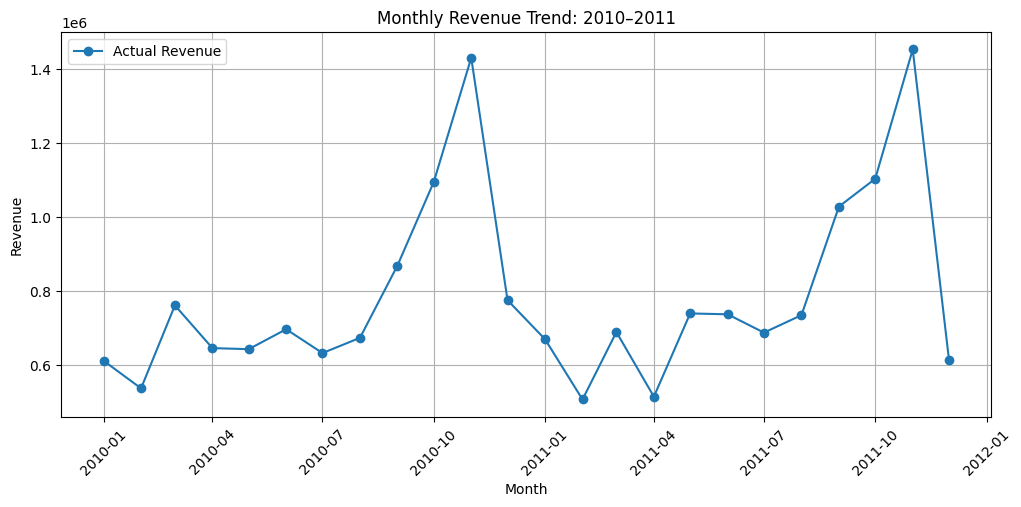

Linear Trend Equation:
Yt = 634413.72 + 12111.64t


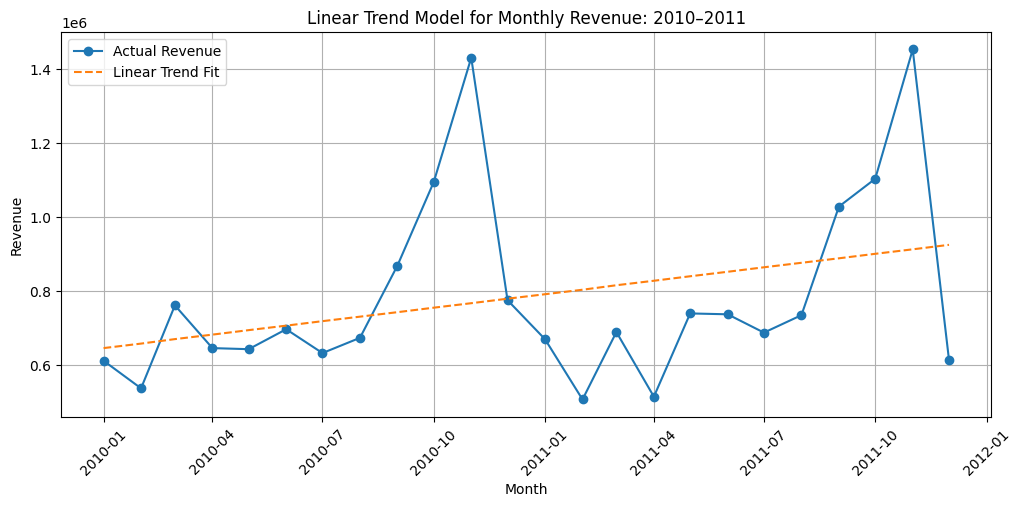

Linear Trend Accuracy Measures
MAPE: 21.59%
MAD: 174932.12
MSD: 56081907367.82
MonthStart
2010-01-01    612455.50
2010-02-01    537932.64
2010-03-01    761748.53
2010-04-01    646478.06
2010-05-01    643585.64
Freq: MS, Name: Revenue, dtype: float64


,0
2012-01-01,6.697305e+05
2012-02-01,5.162780e+05
2012-03-01,6.961319e+05
2012-04-01,5.242288e+05
2012-05-01,6.990251e+05
2012-06-01,7.050760e+05
2012-07-01,6.245500e+05
2012-08-01,6.588497e+05
2012-09-01,8.596888e+05
2012-10-01,1.042628e+06


In [ ]:
# =========================
# 1. Install / Import Libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing


# =========================
# 2. Load Dataset
# =========================

df = pd.read_excel("cleaned_online_retail (1).xlsx")

df.head()


# =========================
# 3. Prepare Date and Revenue Columns
# =========================

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# If Revenue already exists, use it.
# If not, create it.
if "Revenue" not in df.columns:
    df["Revenue"] = df["Quantity"] * df["Price"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month

# =========================
# 4. Filter for 2010 and 2011 Only
# =========================

df_2010_2011 = df[df["Year"].isin([2010, 2011])].copy()

df_2010_2011.shape

# =========================
# 5. Aggregate Revenue by Month
# =========================

monthly_revenue = (
    df_2010_2011
    .groupby(pd.Grouper(key="InvoiceDate", freq="MS"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue = monthly_revenue.rename(columns={"InvoiceDate": "MonthStart"})

monthly_revenue["Year"] = monthly_revenue["MonthStart"].dt.year
monthly_revenue["Month"] = monthly_revenue["MonthStart"].dt.month
monthly_revenue["Month_Name"] = monthly_revenue["MonthStart"].dt.strftime("%b")
monthly_revenue["Month_Label"] = monthly_revenue["MonthStart"].dt.strftime("%b-%Y")

monthly_revenue


# =========================
# 6. Monthly Revenue Trend Plot
# =========================

plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["MonthStart"],
    monthly_revenue["Revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.title("Monthly Revenue Trend: 2010–2011")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 7. Linear Trend Model
# =========================

monthly_revenue["t"] = np.arange(1, len(monthly_revenue) + 1)

X = monthly_revenue[["t"]]
y = monthly_revenue["Revenue"]

linear_model = LinearRegression()
linear_model.fit(X, y)

monthly_revenue["Linear_Fit"] = linear_model.predict(X)

intercept = linear_model.intercept_
slope = linear_model.coef_[0]

print("Linear Trend Equation:")
print(f"Yt = {intercept:.2f} + {slope:.2f}t")


# =========================
# 8. Linear Trend Plot
# =========================

plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["MonthStart"],
    monthly_revenue["Revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    monthly_revenue["MonthStart"],
    monthly_revenue["Linear_Fit"],
    linestyle="--",
    label="Linear Trend Fit"
)

plt.title("Linear Trend Model for Monthly Revenue: 2010–2011")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

# =========================
# 9. Accuracy Measures for Linear Trend
# =========================

actual = monthly_revenue["Revenue"]
fit = monthly_revenue["Linear_Fit"]

MAPE = np.mean(np.abs((actual - fit) / actual)) * 100
MAD = mean_absolute_error(actual, fit)
MSD = mean_squared_error(actual, fit)

print("Linear Trend Accuracy Measures")
print(f"MAPE: {MAPE:.2f}%")
print(f"MAD: {MAD:.2f}")
print(f"MSD: {MSD:.2f}")

# =========================
# 11. Holt-Winters / Winter's Method
# =========================
# Since we only have around 24 months, seasonal_periods=12 is okay,
# but results should be interpreted cautiously.

# Create the time series

ts = monthly_revenue.set_index("MonthStart")["Revenue"]

# Ensure monthly frequency
ts = ts.asfreq("MS")

print(ts.head())

hw_model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit(
    smoothing_level=0.2,
    smoothing_trend=0.2,
    smoothing_seasonal=0.2,
    optimized=False
)

monthly_revenue["HW_Fitted"] = hw_model.fittedvalues.values

forecast_periods = 12

hw_forecast = hw_model.forecast(forecast_periods)

hw_forecast

In [ ]:
# =========================
# Export Linear Monthly Trend Analysis for Power BI
# =========================

powerbi_linear = monthly_revenue.copy()

powerbi_linear["MonthStart"] = pd.to_datetime(powerbi_linear["MonthStart"])
powerbi_linear["Year"] = powerbi_linear["MonthStart"].dt.year
powerbi_linear["Month"] = powerbi_linear["MonthStart"].dt.month
powerbi_linear["Month_Name"] = powerbi_linear["MonthStart"].dt.strftime("%b")
powerbi_linear["Month_Year"] = powerbi_linear["MonthStart"].dt.strftime("%Y-%m")

# Add model information
powerbi_linear["Trend_Intercept"] = intercept
powerbi_linear["Trend_Slope"] = slope
powerbi_linear["Trend_Equation"] = f"Yt = {intercept:.2f} + {slope:.2f}t"

# Add error columns
powerbi_linear["Error"] = powerbi_linear["Revenue"] - powerbi_linear["Linear_Fit"]
powerbi_linear["Absolute_Error"] = abs(powerbi_linear["Error"])
powerbi_linear["Absolute_Percentage_Error"] = (
    powerbi_linear["Absolute_Error"] / powerbi_linear["Revenue"]
)

# Add model accuracy metrics
powerbi_linear["MAPE"] = MAPE / 100
powerbi_linear["MAD"] = MAD
powerbi_linear["MSD"] = MSD

# Keep Power BI-friendly columns
powerbi_linear = powerbi_linear[
    [
        "MonthStart",
        "Year",
        "Month",
        "Month_Name",
        "Month_Year",
        "t",
        "Revenue",
        "Linear_Fit",
        "Error",
        "Absolute_Error",
        "Absolute_Percentage_Error",
        "MAPE",
        "MAD",
        "MSD",
        "Trend_Intercept",
        "Trend_Slope",
        "Trend_Equation"
    ]
]

powerbi_linear.to_csv("PowerBI_Linear_Monthly_Trend.csv", index=False)

powerbi_linear.head()

,MonthStart,Year,Month,Month_Name,Month_Year,t,Revenue,Linear_Fit,Error,Absolute_Error,Absolute_Percentage_Error,MAPE,MAD,MSD,Trend_Intercept,Trend_Slope,Trend_Equation
0,2010-01-01,2010,1,Jan,2010-01,1,612455.50,646525.352433,-34069.852433,34069.852433,0.055628,0.215924,174932.123814,5.608191e+10,634413.716703,12111.63573,Yt = 634413.72 + 12111.64t
1,2010-02-01,2010,2,Feb,2010-02,2,537932.64,658636.988164,-120704.348164,120704.348164,0.224386,0.215924,174932.123814,5.608191e+10,634413.716703,12111.63573,Yt = 634413.72 + 12111.64t
2,2010-03-01,2010,3,Mar,2010-03,3,761748.53,670748.623894,90999.906106,90999.906106,0.119462,0.215924,174932.123814,5.608191e+10,634413.716703,12111.63573,Yt = 634413.72 + 12111.64t
3,2010-04-01,2010,4,Apr,2010-04,4,646478.06,682860.259625,-36382.199625,36382.199625,0.056278,0.215924,174932.123814,5.608191e+10,634413.716703,12111.63573,Yt = 634413.72 + 12111.64t
4,2010-05-01,2010,5,May,2010-05,5,643585.64,694971.895355,-51386.255355,51386.255355,0.079844,0.215924,174932.123814,5.608191e+10,634413.716703,12111.63573,Yt = 634413.72 + 12111.64t


In [ ]:
from google.colab import files
files.download("PowerBI_Linear_Monthly_Trend.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

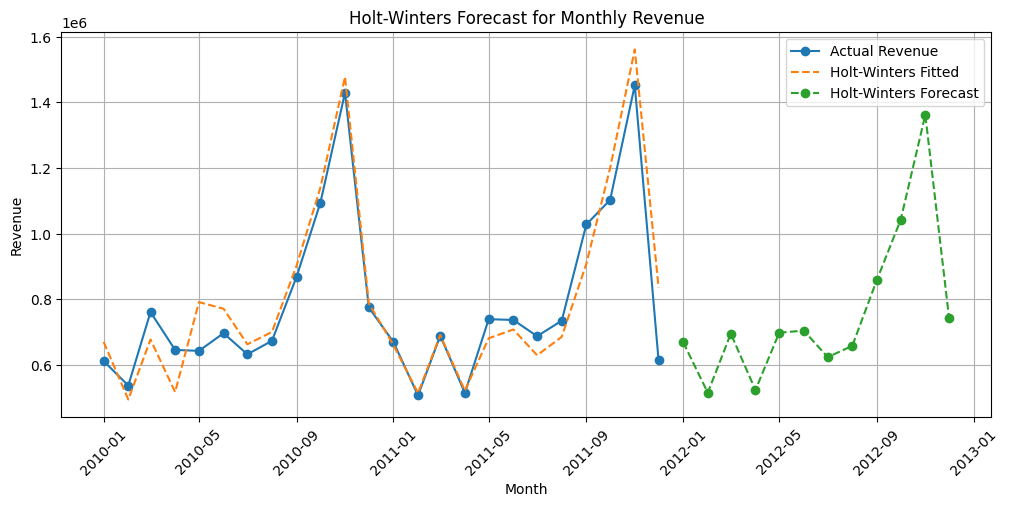

Holt-Winters Accuracy Measures
MAPE: 8.30%
MAD: 62544.85
MSD: 6611664046.37


,Model,MAPE,MAD,MSD
0,Linear Trend,21.592383,174932.123814,5.608191e+10
1,Holt-Winters,8.303742,62544.849897,6.611664e+09


In [ ]:
# =========================
# 12. Holt-Winters Forecast Plot
# =========================

plt.figure(figsize=(12,5))

plt.plot(
    ts.index,
    ts.values,
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    hw_model.fittedvalues.index,
    hw_model.fittedvalues.values,
    linestyle="--",
    label="Holt-Winters Fitted"
)

plt.plot(
    hw_forecast.index,
    hw_forecast.values,
    marker="o",
    linestyle="--",
    label="Holt-Winters Forecast"
)

plt.title("Holt-Winters Forecast for Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 13. Accuracy Measures for Holt-Winters
# =========================

actual_hw = ts
fitted_hw = hw_model.fittedvalues

MAPE_HW = np.mean(np.abs((actual_hw - fitted_hw) / actual_hw)) * 100
MAD_HW = mean_absolute_error(actual_hw, fitted_hw)
MSD_HW = mean_squared_error(actual_hw, fitted_hw)

print("Holt-Winters Accuracy Measures")
print(f"MAPE: {MAPE_HW:.2f}%")
print(f"MAD: {MAD_HW:.2f}")
print(f"MSD: {MSD_HW:.2f}")

# =========================
# 14. Compare Linear vs Holt-Winters
# =========================

comparison = pd.DataFrame({
    "Model": ["Linear Trend", "Holt-Winters"],
    "MAPE": [MAPE, MAPE_HW],
    "MAD": [MAD, MAD_HW],
    "MSD": [MSD, MSD_HW]
})

comparison

In [ ]:
# =========================
# Export Holt-Winters for Power BI
# =========================

actual_df = ts.reset_index()
actual_df.columns = ["MonthStart", "Actual_Revenue"]

fitted_df = fitted_hw.reset_index()
fitted_df.columns = ["MonthStart", "Fitted_Revenue"]

forecast_df = hw_forecast.reset_index()
forecast_df.columns = ["MonthStart", "Forecast_Revenue"]

powerbi_hw = actual_df.merge(
    fitted_df,
    on="MonthStart",
    how="left"
).merge(
    forecast_df,
    on="MonthStart",
    how="outer"
)

powerbi_hw["MonthStart"] = pd.to_datetime(powerbi_hw["MonthStart"])
powerbi_hw["Year"] = powerbi_hw["MonthStart"].dt.year
powerbi_hw["Month"] = powerbi_hw["MonthStart"].dt.month
powerbi_hw["Month_Year"] = powerbi_hw["MonthStart"].dt.strftime("%Y-%m")

powerbi_hw.to_csv("PowerBI_Holt_Winters_Forecast.csv", index=False)

powerbi_hw.head()

,MonthStart,Actual_Revenue,Fitted_Revenue,Forecast_Revenue,Year,Month,Month_Year
0,2010-01-01,612455.50,670802.537162,NaN,2010,1,2010-01
1,2010-02-01,537932.64,495567.149507,NaN,2010,2,2010-02
2,2010-03-01,761748.53,678135.734283,NaN,2010,3,2010-03
3,2010-04-01,646478.06,518201.586245,NaN,2010,4,2010-04
4,2010-05-01,643585.64,791919.975735,NaN,2010,5,2010-05


In [ ]:
from google.colab import files
files.download("PowerBI_Holt_Winters_Forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# 1. Import libraries
# =========================

import pandas as pd
import numpy as np

# =========================
# 2. Load Retail Categorized file
# =========================

import pandas as pd

df = pd.read_excel("Retail_Categorized.xlsx")

print(df.head())

print("Dataset loaded successfully")
print(df.shape)
print(df.columns.tolist())

# =========================
# 3. Prepare columns
# =========================

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

if "Revenue" not in df.columns:
    df["Revenue"] = df["Quantity"] * df["Price"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Month_Year"] = df["InvoiceDate"].dt.strftime("%b-%Y")

# =========================
# 4. Monthly Demand Trend
# =========================

monthly_demand = (
    df.groupby(pd.Grouper(key="InvoiceDate", freq="MS"))["Quantity"]
    .sum()
    .reset_index()
)

monthly_demand["Year"] = monthly_demand["InvoiceDate"].dt.year
monthly_demand["Month"] = monthly_demand["InvoiceDate"].dt.month
monthly_demand["Month_Name"] = monthly_demand["InvoiceDate"].dt.month_name()
monthly_demand["Month_Year"] = monthly_demand["InvoiceDate"].dt.strftime("%b-%Y")

monthly_demand.to_csv("PowerBI_Monthly_Demand_Trend.csv", index=False)

# =========================
# 5. Quantity Sold by Category
# =========================

quantity_by_category = (
    df.groupby("Category")["Quantity"]
    .sum()
    .reset_index()
    .sort_values("Quantity", ascending=False)
)

quantity_by_category.to_csv("PowerBI_Quantity_By_Category.csv", index=False)

# =========================
# 6. ABC Classification
# =========================

abc = (
    df.groupby(["StockCode", "Description", "Category"])
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

abc["Revenue_Percentage"] = abc["Total_Revenue"] / abc["Total_Revenue"].sum() * 100
abc["Cumulative_Revenue_Percentage"] = abc["Revenue_Percentage"].cumsum()

def abc_classify(x):
    if x <= 80:
        return "A"
    elif x <= 95:
        return "B"
    else:
        return "C"

abc["ABC_Class"] = abc["Cumulative_Revenue_Percentage"].apply(abc_classify)

abc.to_csv("PowerBI_ABC_Classification.csv", index=False)

# =========================
# 7. Top Fast-Moving Products
# =========================

fast_moving_products = (
    df.groupby(["StockCode", "Description", "Category"])
    .agg(
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("Revenue", "sum")
    )
    .reset_index()
    .sort_values("Total_Quantity", ascending=False)
    .head(20)
)

fast_moving_products.to_csv("PowerBI_Top_Fast_Moving_Products.csv", index=False)

# =========================
# 8. Top Slow-Moving Products
# =========================

slow_moving_products = (
    df.groupby(["StockCode", "Description", "Category"])
    .agg(
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

slow_moving_products = slow_moving_products[slow_moving_products["Total_Quantity"] > 0]

slow_moving_products = (
    slow_moving_products
    .sort_values("Total_Quantity", ascending=True)
    .head(20)
)

slow_moving_products.to_csv("PowerBI_Top_Slow_Moving_Products.csv", index=False)

# =========================
# 9. Inventory Planning Table
# =========================

lead_time_days = 7
z_score = 1.65

daily_demand = (
    df.groupby(["Category", df["InvoiceDate"].dt.date])["Quantity"]
    .sum()
    .reset_index()
)

daily_demand.columns = ["Category", "Date", "Daily_Demand"]

inventory_table = (
    daily_demand.groupby("Category")
    .agg(
        Avg_Daily_Demand=("Daily_Demand", "mean"),
        Std_Daily_Demand=("Daily_Demand", "std"),
        Max_Daily_Demand=("Daily_Demand", "max")
    )
    .reset_index()
)

inventory_table["Avg_Monthly_Demand"] = inventory_table["Avg_Daily_Demand"] * 30

inventory_table["Safety_Stock"] = (
    z_score * inventory_table["Std_Daily_Demand"] * np.sqrt(lead_time_days)
)

inventory_table["Reorder_Point"] = (
    inventory_table["Avg_Daily_Demand"] * lead_time_days
    + inventory_table["Safety_Stock"]
)

inventory_table["Forecast_Demand"] = inventory_table["Avg_Monthly_Demand"]

inventory_table = inventory_table.fillna(0).round(2)

inventory_table.to_csv("PowerBI_Inventory_Planning_Table.csv", index=False)

# =========================
# 10. Main Power BI Dataset
# =========================

df.to_csv("PowerBI_Main_Categorized_Dataset.csv", index=False)

# =========================
# 11. Check outputs
# =========================

print("Files created successfully:")
print("1. PowerBI_Main_Categorized_Dataset.csv")
print("2. PowerBI_Monthly_Demand_Trend.csv")
print("3. PowerBI_Quantity_By_Category.csv")
print("4. PowerBI_ABC_Classification.csv")
print("5. PowerBI_Top_Fast_Moving_Products.csv")
print("6. PowerBI_Top_Slow_Moving_Products.csv")
print("7. PowerBI_Inventory_Planning_Table.csv")

  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  IsCancellation  \
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom           False   
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom           False   
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom           False   
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom           False   
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom           False   

   TotalPrice    Category  Year  Month  
0        83.4   Christmas  2009     12  
1        81.0    Lighting  2009   

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country', 'IsCancellation', 'TotalPrice', 'Category', 'Year', 'Month', 'Revenue']


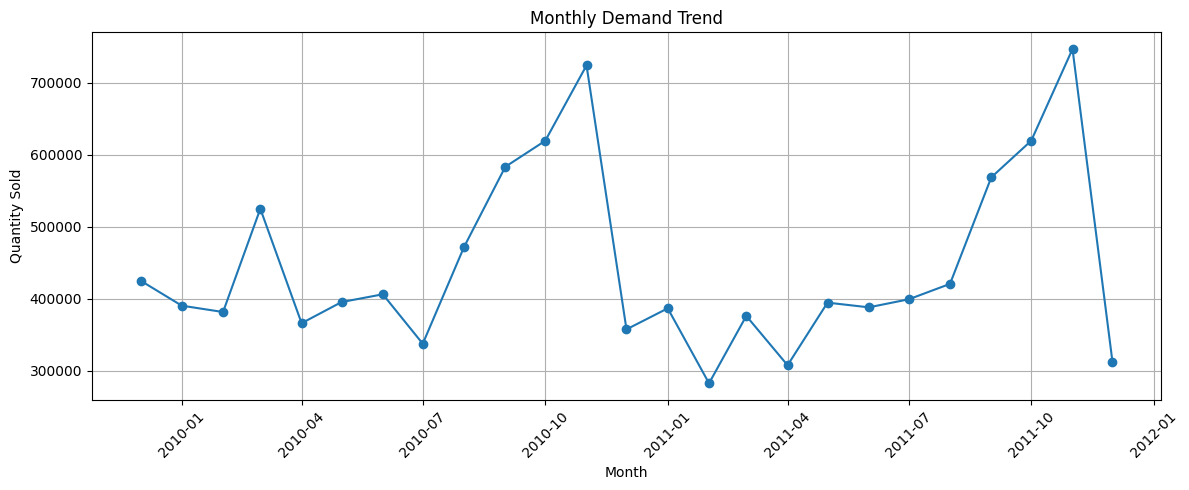

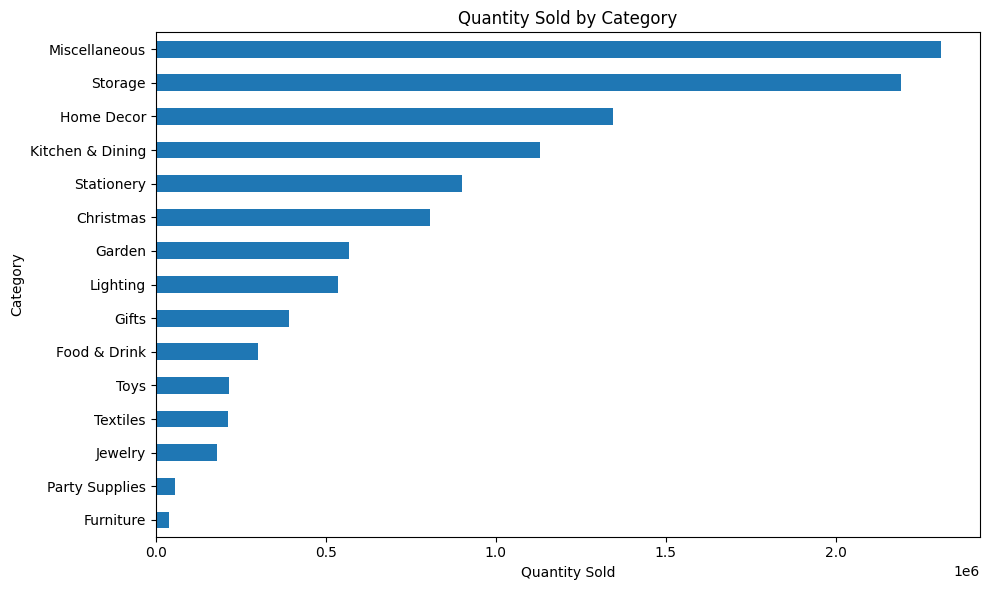

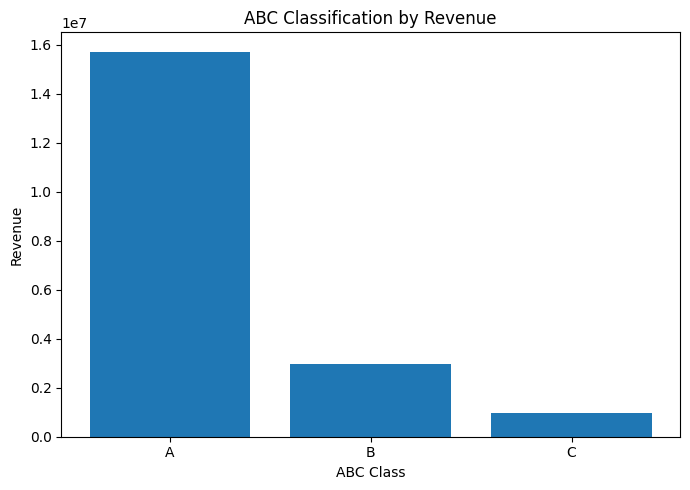

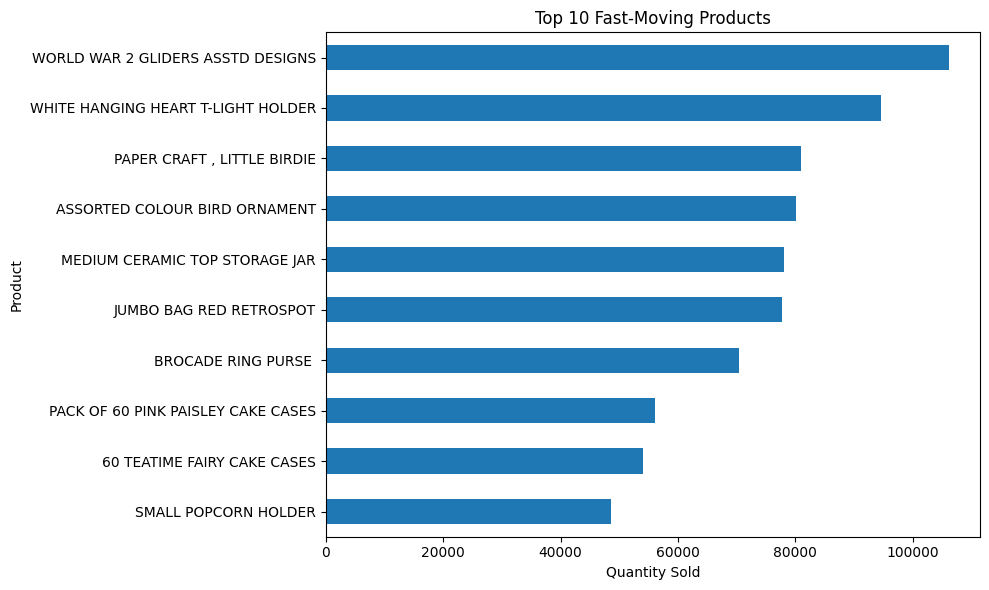

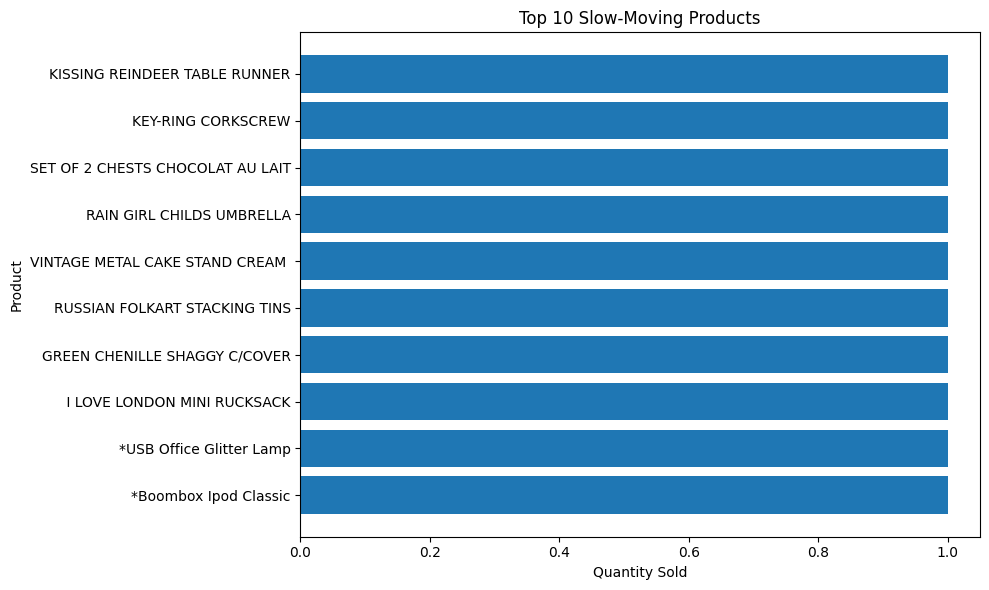

,Category,Avg_Daily_Demand,Std_Daily_Demand,Max_Daily_Demand,Avg_Monthly_Demand,Safety_Stock,Reorder_Point
0,Christmas,1335.99,1603.74,10409,40079.55,7001.12,16353.02
1,Food & Drink,498.07,440.45,3152,14942.24,1922.76,5409.28
2,Furniture,67.84,129.88,1347,2035.23,567.00,1041.89
3,Garden,939.31,803.10,11482,28179.34,3505.91,10081.09
4,Gifts,648.92,606.63,7823,19467.72,2648.23,7190.70
5,Home Decor,2228.32,1414.31,18127,66849.64,6174.16,21772.40
6,Jewelry,297.25,615.04,11168,8917.36,2684.96,4765.67
7,Kitchen & Dining,1872.32,3772.00,65741,56169.74,16466.63,29572.90
8,Lighting,888.70,881.51,10530,26660.96,3848.23,10069.12
9,Miscellaneous,3823.57,2874.03,33928,114707.04,12546.55,39311.52


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load file
df = pd.read_excel("Retail_Categorized.xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Prepare data
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

if "Revenue" not in df.columns:
    df["Revenue"] = df["Quantity"] * df["Price"]

print(df.columns.tolist())

monthly_demand = (
    df.groupby(pd.Grouper(key="InvoiceDate", freq="MS"))["Quantity"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(monthly_demand["InvoiceDate"], monthly_demand["Quantity"], marker="o")
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("Monthly_Demand_Trend.png")
plt.show()


quantity_by_category = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))
quantity_by_category.plot(kind="barh")
plt.title("Quantity Sold by Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("Quantity_Sold_By_Category.png")
plt.show()

#ABC Classification

abc = (
    df.groupby(["StockCode", "Description", "Category"])
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

abc["Revenue_Percentage"] = abc["Total_Revenue"] / abc["Total_Revenue"].sum() * 100
abc["Cumulative_Revenue_Percentage"] = abc["Revenue_Percentage"].cumsum()

abc["ABC_Class"] = np.where(
    abc["Cumulative_Revenue_Percentage"] <= 80, "A",
    np.where(abc["Cumulative_Revenue_Percentage"] <= 95, "B", "C")
)

abc_summary = abc.groupby("ABC_Class")["Total_Revenue"].sum().reset_index()

plt.figure(figsize=(7,5))
plt.bar(abc_summary["ABC_Class"], abc_summary["Total_Revenue"])
plt.title("ABC Classification by Revenue")
plt.xlabel("ABC Class")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("ABC_Classification.png")
plt.show()

#Top fast moving products

fast_moving = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))
fast_moving.plot(kind="barh")
plt.title("Top 10 Fast-Moving Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("Top_Fast_Moving_Products.png")
plt.show()

#Top slow moving products

slow_moving = (
    df.groupby("Description")["Quantity"]
    .sum()
    .reset_index()
)

slow_moving = slow_moving[slow_moving["Quantity"] > 0]

slow_moving = (
    slow_moving
    .sort_values("Quantity", ascending=True)
    .head(10)
    .sort_values("Quantity")
)

plt.figure(figsize=(10,6))
plt.barh(slow_moving["Description"], slow_moving["Quantity"])
plt.title("Top 10 Slow-Moving Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("Top_Slow_Moving_Products.png")
plt.show()

#inventory planning table
lead_time_days = 7
z_score = 1.65

daily_demand = (
    df.groupby(["Category", df["InvoiceDate"].dt.date])["Quantity"]
    .sum()
    .reset_index()
)

daily_demand.columns = ["Category", "Date", "Daily_Demand"]

inventory_table = (
    daily_demand.groupby("Category")
    .agg(
        Avg_Daily_Demand=("Daily_Demand", "mean"),
        Std_Daily_Demand=("Daily_Demand", "std"),
        Max_Daily_Demand=("Daily_Demand", "max")
    )
    .reset_index()
)

inventory_table["Avg_Monthly_Demand"] = inventory_table["Avg_Daily_Demand"] * 30
inventory_table["Safety_Stock"] = z_score * inventory_table["Std_Daily_Demand"] * np.sqrt(lead_time_days)
inventory_table["Reorder_Point"] = inventory_table["Avg_Daily_Demand"] * lead_time_days + inventory_table["Safety_Stock"]
inventory_table = inventory_table.fillna(0).round(2)

inventory_table

In [ ]:
abc = (
    df.groupby(["StockCode", "Description", "Category"])
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

abc = abc.sort_values("Total_Revenue", ascending=False)

abc["Revenue_Percentage"] = abc["Total_Revenue"] / abc["Total_Revenue"].sum() * 100
abc["Cumulative_Revenue_Percentage"] = abc["Revenue_Percentage"].cumsum()

abc["ABC_Class"] = np.where(
    abc["Cumulative_Revenue_Percentage"] <= 80,
    "A",
    np.where(
        abc["Cumulative_Revenue_Percentage"] <= 95,
        "B",
        "C"
    )
)

abc.to_csv("PowerBI_ABC_With_Category.csv", index=False)

/tmp/ipykernel_16574/288596668.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


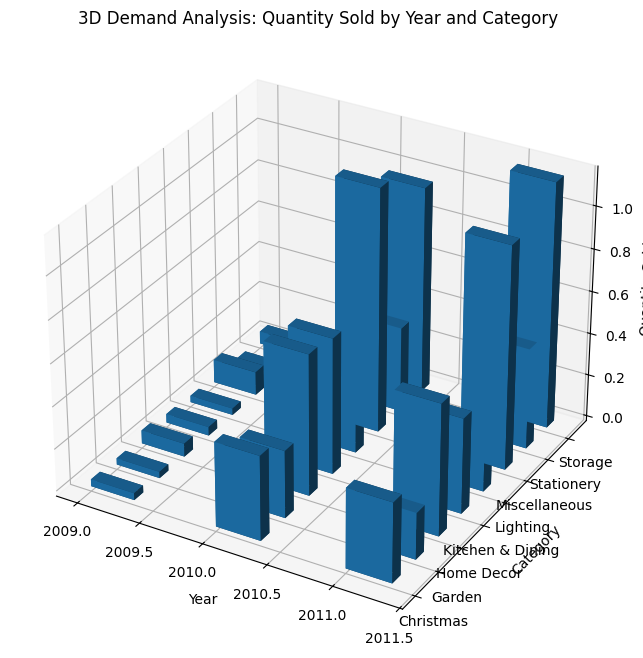

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load categorized file
df = pd.read_excel("Retail_Categorized.xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Date conversion
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create year
df["Year"] = df["InvoiceDate"].dt.year

# Aggregate Quantity by Year and Category
category_year_qty = (
    df.groupby(["Year", "Category"])["Quantity"]
    .sum()
    .reset_index()
)

# Keep top 8 categories by total quantity for readability
top_categories = (
    category_year_qty.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_data = category_year_qty[
    category_year_qty["Category"].isin(top_categories)
].copy()

# Convert categories to numeric positions
category_labels = sorted(plot_data["Category"].unique())
category_map = {cat: i for i, cat in enumerate(category_labels)}

plot_data["Category_Num"] = plot_data["Category"].map(category_map)

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

x = plot_data["Year"]
y = plot_data["Category_Num"]
z = np.zeros(len(plot_data))

dx = 0.35
dy = 0.35
dz = plot_data["Quantity"]

ax.bar3d(x, y, z, dx, dy, dz)

ax.set_title("3D Demand Analysis: Quantity Sold by Year and Category")
ax.set_xlabel("Year")
ax.set_ylabel("Category")
ax.set_zlabel("Quantity Sold")

ax.set_yticks(range(len(category_labels)))
ax.set_yticklabels(category_labels)

plt.tight_layout()
plt.savefig("3D_Quantity_By_Year_Category.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# =========================
# 1. Load categorized dataset
# =========================

df = pd.read_excel("Retail_Categorized.xlsx")

# Clean column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Convert date
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# =========================
# 2. Basic setup
# =========================

lead_time_days = 7
z_score = 1.65   # 95% service level

# =========================
# 3. Daily demand by category
# =========================

daily_demand = (
    df.groupby(["Category", df["InvoiceDate"].dt.date])["Quantity"]
    .sum()
    .reset_index()
)

daily_demand.columns = ["Category", "Date", "Daily_Demand"]
daily_demand["Date"] = pd.to_datetime(daily_demand["Date"])

# =========================
# 4. Monthly demand by category
# =========================

monthly_demand = (
    df.groupby(["Category", pd.Grouper(key="InvoiceDate", freq="MS")])["Quantity"]
    .sum()
    .reset_index()
)

monthly_demand = monthly_demand.rename(columns={"InvoiceDate": "MonthStart"})

# =========================
# 5. Holt-Winters forecast by category
# =========================

forecast_results = []

for category in monthly_demand["Category"].unique():

    category_data = monthly_demand[
        monthly_demand["Category"] == category
    ].copy()

    ts = category_data.set_index("MonthStart")["Quantity"]
    ts = ts.asfreq("MS")

    # Fill missing months with 0 demand
    ts = ts.fillna(0)

    try:
        # Holt-Winters model
        model = ExponentialSmoothing(
            ts,
            trend="add",
            seasonal="mul",
            seasonal_periods=12
        ).fit(optimized=True)

        forecast = model.forecast(1).iloc[0]

    except:
        # Fallback if category has insufficient history
        forecast = ts.mean()

    forecast_results.append({
        "Category": category,
        "Forecast_Demand_Next_Month": forecast
    })

forecast_df = pd.DataFrame(forecast_results)

# =========================
# 6. Inventory planning calculations
# =========================

inventory_table = (
    daily_demand.groupby("Category")
    .agg(
        Avg_Daily_Demand=("Daily_Demand", "mean"),
        Std_Daily_Demand=("Daily_Demand", "std"),
        Max_Daily_Demand=("Daily_Demand", "max")
    )
    .reset_index()
)

inventory_table["Avg_Monthly_Demand"] = (
    inventory_table["Avg_Daily_Demand"] * 30
)

# Merge Holt-Winters forecast
inventory_table = inventory_table.merge(
    forecast_df,
    on="Category",
    how="left"
)

# Safety stock
inventory_table["Safety_Stock"] = (
    z_score
    * inventory_table["Std_Daily_Demand"]
    * np.sqrt(lead_time_days)
)

# Reorder point using forecast demand
inventory_table["Forecast_Daily_Demand"] = (
    inventory_table["Forecast_Demand_Next_Month"] / 30
)

inventory_table["Reorder_Point"] = (
    inventory_table["Forecast_Daily_Demand"] * lead_time_days
    + inventory_table["Safety_Stock"]
)

inventory_table = inventory_table.fillna(0).round(2)

# =========================
# 7. Save output
# =========================

inventory_table.to_csv(
    "Inventory_Planning_Holt_Winters.csv",
    index=False
)

inventory_table

,Category,Avg_Daily_Demand,Std_Daily_Demand,Max_Daily_Demand,Avg_Monthly_Demand,Forecast_Demand_Next_Month,Safety_Stock,Forecast_Daily_Demand,Reorder_Point
0,Christmas,1335.99,1603.74,10409,40079.55,14867.38,7001.12,495.58,10470.18
1,Food & Drink,498.07,440.45,3152,14942.24,7368.89,1922.76,245.63,3642.17
2,Furniture,67.84,129.88,1347,2035.23,1.73,567.00,0.06,567.40
3,Garden,939.31,803.10,11482,28179.34,7262.38,3505.91,242.08,5200.46
4,Gifts,648.92,606.63,7823,19467.72,13824.74,2648.23,460.82,5874.01
5,Home Decor,2228.32,1414.31,18127,66849.64,39030.55,6174.16,1301.02,15281.28
6,Jewelry,297.25,615.04,11168,8917.36,2064.08,2684.96,68.80,3166.58
7,Kitchen & Dining,1872.32,3772.00,65741,56169.74,17279.62,16466.63,575.99,20498.54
8,Lighting,888.70,881.51,10530,26660.96,10512.94,3848.23,350.43,6301.25
9,Miscellaneous,3823.57,2874.03,33928,114707.04,58991.23,12546.55,1966.37,26311.17


In [ ]:
# =========================
# Summarized Inventory Planning Table
# =========================

summary_inventory = inventory_table.copy()

# Create Inventory Priority
def priority(row):
    if row["Reorder_Point"] >= summary_inventory["Reorder_Point"].quantile(0.75):
        return "High Priority"
    elif row["Reorder_Point"] >= summary_inventory["Reorder_Point"].quantile(0.40):
        return "Medium Priority"
    else:
        return "Low Priority"

summary_inventory["Inventory_Priority"] = summary_inventory.apply(priority, axis=1)

# Create Suggested Action
def action(row):
    if row["Inventory_Priority"] == "High Priority":
        return "Increase stock / monitor closely"
    elif row["Inventory_Priority"] == "Medium Priority":
        return "Maintain normal replenishment"
    else:
        return "Review demand / avoid overstock"

summary_inventory["Suggested_Action"] = summary_inventory.apply(action, axis=1)

# Keep only executive-friendly columns
summary_inventory = summary_inventory[
    [
        "Category",
        "Forecast_Demand_Next_Month",
        "Safety_Stock",
        "Reorder_Point",
        "Inventory_Priority",
        "Suggested_Action"
    ]
]

# Rename columns for Power BI / presentation
summary_inventory = summary_inventory.rename(columns={
    "Forecast_Demand_Next_Month": "Forecast Demand",
    "Safety_Stock": "Safety Stock",
    "Reorder_Point": "Reorder Point",
    "Inventory_Priority": "Priority",
    "Suggested_Action": "Suggested Action"
})

summary_inventory = summary_inventory.round(2)

summary_inventory.to_csv("Inventory_Planning_Summary.csv", index=False)

summary_inventory

,Category,Forecast Demand,Safety Stock,Reorder Point,Priority,Suggested Action
0,Christmas,14867.38,7001.12,10470.18,Medium Priority,Maintain normal replenishment
1,Food & Drink,7368.89,1922.76,3642.17,Low Priority,Review demand / avoid overstock
2,Furniture,1.73,567.00,567.40,Low Priority,Review demand / avoid overstock
3,Garden,7262.38,3505.91,5200.46,Medium Priority,Maintain normal replenishment
4,Gifts,13824.74,2648.23,5874.01,Medium Priority,Maintain normal replenishment
5,Home Decor,39030.55,6174.16,15281.28,Medium Priority,Maintain normal replenishment
6,Jewelry,2064.08,2684.96,3166.58,Low Priority,Review demand / avoid overstock
7,Kitchen & Dining,17279.62,16466.63,20498.54,High Priority,Increase stock / monitor closely
8,Lighting,10512.94,3848.23,6301.25,Medium Priority,Maintain normal replenishment
9,Miscellaneous,58991.23,12546.55,26311.17,High Priority,Increase stock / monitor closely


In [ ]:
from google.colab import files

files.download("Inventory_Planning_Holt_Winters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
summary_inventory.to_csv("PowerBI_Inventory_Planning_Summary.csv", index=False)

from google.colab import files
files.download("PowerBI_Inventory_Planning_Summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>